In [1]:
import sys
from pathlib import Path
import os
import time
import glob
import itertools
import shutil
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
from astropy.timeseries import LombScargle
import numpy as np
import pandas as pd
from collections import Counter

PROJECT_ROOT = Path.cwd().parents[0]   # adjust if needed
sys.path.append(str(PROJECT_ROOT))

from src.jdr import jdr, jdr_parallel
from src.JDRKMedoids import JDRKMedoids
from src.JDRDBSCAN import JDRDBSCAN
from collections import Counter
import re


precomputed_distance = True

In [2]:
PROJECT_ROOT

PosixPath('/home/franciscoperez/Documents/GitHub/JDR-Python')

In [3]:
# Directory containing .dat files
data_dir = "../data"

# Find RR Lyrae .dat files. Increase n_files if needed.
n_files = 30
min_period=0.1
max_period=2

files = sorted(glob.glob(os.path.join(data_dir, "*RRLYR*.dat")))[:n_files]

print(f"Found {len(files)} files")


Found 30 files


In [4]:
def read_light_curve(filepath, n_sample=300):
    # Read a light curve with columns time, magnitude, and optionally error.
    lc = pd.read_csv(filepath, sep=r"\s+", header=None, comment="#")
    if lc.shape[0]>n_sample:
        lc = lc.sample(n_sample)
    t = lc.iloc[:, 0].to_numpy(dtype=float)
    mag = lc.iloc[:, 1].to_numpy(dtype=float)
    err = lc.iloc[:, 2].to_numpy(dtype=float) if lc.shape[1] > 2 else None
    return t, mag, err


def estimate_period(dat_file, min_period=min_period, max_period=max_period, n_freq=20000):
    # Estimate the dominant period using Lomb--Scargle.
    t, mag, _ = read_light_curve(dat_file)
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]

    if len(t) < 5:
        raise ValueError(f"Not enough finite observations to estimate period: {dat_file}")

    freq = np.linspace(1 / max_period, 1 / min_period, n_freq)
    power = LombScargle(t, mag).power(freq)
    best_freq = freq[np.argmax(power)]
    return 1 / best_freq


def fold_time(t, period, t0=None):
    # Convert observation times to phase in [0, 1).
    if t0 is None:
        t0 = np.nanmin(t)
    return ((t - t0) / period) % 1.0


def write_folded_light_curve(input_file, output_dir, period=None, min_period=min_period, max_period=max_period):
    # Fold a light curve and write a JDR-compatible phase-space .dat file.
    t, mag, err = read_light_curve(input_file)

    if period is None:
        period = estimate_period(input_file, min_period=min_period, max_period=max_period)

    phase = fold_time(t, period)

    mask = np.isfinite(phase) & np.isfinite(mag)
    if err is not None:
        mask &= np.isfinite(err)

    phase = phase[mask]
    mag = mag[mask]
    err = err[mask] if err is not None else None

    order = np.argsort(phase)
    phase = phase[order]
    mag = mag[order]
    if err is not None:
        err = err[order]
        folded = np.column_stack([phase, mag, err])
    else:
        folded = np.column_stack([phase, mag])

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / Path(input_file).name
    np.savetxt(output_file, folded, fmt="%.10f")
    return str(output_file), period


def build_folded_dataset(files, folded_dir="../data/folded_rrlyr", min_period=min_period, max_period=max_period, overwrite=True):
    # Create folded files and return their paths plus the estimated periods.
    folded_dir = Path(folded_dir)
    if overwrite and folded_dir.exists():
        shutil.rmtree(folded_dir)
    folded_dir.mkdir(parents=True, exist_ok=True)

    folded_files = []
    periods = {}

    for f in files:
        folded_f, period = write_folded_light_curve(
            f,
            output_dir=folded_dir,
            period=None,
            min_period=min_period,
            max_period=max_period,
        )
        folded_files.append(folded_f)
        periods[Path(f).stem] = period

    return folded_files, periods


folded_files, periods = build_folded_dataset(
    files,
    folded_dir="../data/folded_rrlyr",
    min_period=min_period,
    max_period=max_period,
    overwrite=True,
)

print(f"Created {len(folded_files)} folded files")
print("First folded file:", folded_files[0] if folded_files else None)


Created 30 folded files
First folded file: ../data/folded_rrlyr/OGLE-BLG-RRLYR-00001.dat


In [5]:
#df_results = pd.DataFrame(results, columns=['file1', 'file2', 'jdr', 'time'])

In [6]:
# Build JDR distance matrix using the folded light curves
if precomputed_distance:
    D = np.load("D_folded.npy")
else:
    D = JDRKMedoids.build_distance_matrix(
        files=folded_files,
        distance_func=jdr_parallel,   # or jdr
        verbose=True
    )
    np.save("D_folded.npy", D)

In [7]:
# Save
#

# Load


In [8]:
eps_values = np.linspace(0.01, 1, 10)
min_samples_values = [2, 3, 4]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = JDRDBSCAN(eps=eps, min_samples=min_samples, verbose=False)
        model.fit(D)
        print(
            f"eps={eps:.4f}, min_samples={min_samples}, "
            f"clusters={model.n_clusters_}, noise={model.n_noise_}"
        )

eps=0.0100, min_samples=2, clusters=0, noise=30
eps=0.0100, min_samples=3, clusters=0, noise=30
eps=0.0100, min_samples=4, clusters=0, noise=30
eps=0.1200, min_samples=2, clusters=0, noise=30
eps=0.1200, min_samples=3, clusters=0, noise=30
eps=0.1200, min_samples=4, clusters=0, noise=30
eps=0.2300, min_samples=2, clusters=0, noise=30
eps=0.2300, min_samples=3, clusters=0, noise=30
eps=0.2300, min_samples=4, clusters=0, noise=30
eps=0.3400, min_samples=2, clusters=0, noise=30
eps=0.3400, min_samples=3, clusters=0, noise=30
eps=0.3400, min_samples=4, clusters=0, noise=30
eps=0.4500, min_samples=2, clusters=1, noise=28
eps=0.4500, min_samples=3, clusters=0, noise=30
eps=0.4500, min_samples=4, clusters=0, noise=30
eps=0.5600, min_samples=2, clusters=3, noise=24
eps=0.5600, min_samples=3, clusters=0, noise=30
eps=0.5600, min_samples=4, clusters=0, noise=30
eps=0.6700, min_samples=2, clusters=3, noise=23
eps=0.6700, min_samples=3, clusters=1, noise=27
eps=0.6700, min_samples=4, clusters=0, n

In [9]:
model = JDRDBSCAN(eps=1.2, min_samples=3, verbose=False)
labels = model.fit_predict(D)
print("Labels:", labels)
print("Number of clusters:", model.n_clusters_) 
print("Number of noise points:", model.n_noise_) 
print("Clusters:", model.clusters_)

Labels: [-1  0 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  0 -1 -1 -1 -1 -1 -1
  1 -1 -1  1  1 -1]
Number of clusters: 2
Number of noise points: 23
Clusters: [[1, 6, 17], [16, 24, 27, 28]]


In [10]:
data_dir

'../data'

In [11]:
cols = ["id", "field", "star_id", "type", "ra", "dec"]

df = pd.read_csv(
    os.path.join("/home/franciscoperez/Documents/GitHub/JDR-Python/notebooks/ident.dat"),
    sep=r"\s+",
    header=None,
    usecols=[0, 1, 2, 3, 4, 5],
    names=cols,
    engine="python"
)

df[['id', 'type']].head()

,id,type
0,OGLE-BLG-RRLYR-00001,RRab
1,OGLE-BLG-RRLYR-00002,RRc
2,OGLE-BLG-RRLYR-00003,RRab
3,OGLE-BLG-RRLYR-00004,RRab
4,OGLE-BLG-RRLYR-00005,RRab


In [12]:
files

['../data/OGLE-BLG-RRLYR-00001.dat',
 '../data/OGLE-BLG-RRLYR-00002.dat',
 '../data/OGLE-BLG-RRLYR-00003.dat',
 '../data/OGLE-BLG-RRLYR-00004.dat',
 '../data/OGLE-BLG-RRLYR-00005.dat',
 '../data/OGLE-BLG-RRLYR-00006.dat',
 '../data/OGLE-BLG-RRLYR-00007.dat',
 '../data/OGLE-BLG-RRLYR-00008.dat',
 '../data/OGLE-BLG-RRLYR-00009.dat',
 '../data/OGLE-BLG-RRLYR-00010.dat',
 '../data/OGLE-BLG-RRLYR-00011.dat',
 '../data/OGLE-BLG-RRLYR-00012.dat',
 '../data/OGLE-BLG-RRLYR-00013.dat',
 '../data/OGLE-BLG-RRLYR-00014.dat',
 '../data/OGLE-BLG-RRLYR-00015.dat',
 '../data/OGLE-BLG-RRLYR-00016.dat',
 '../data/OGLE-BLG-RRLYR-00017.dat',
 '../data/OGLE-BLG-RRLYR-00018.dat',
 '../data/OGLE-BLG-RRLYR-00019.dat',
 '../data/OGLE-BLG-RRLYR-00020.dat',
 '../data/OGLE-BLG-RRLYR-00021.dat',
 '../data/OGLE-BLG-RRLYR-00022.dat',
 '../data/OGLE-BLG-RRLYR-00023.dat',
 '../data/OGLE-BLG-RRLYR-00024.dat',
 '../data/OGLE-BLG-RRLYR-00025.dat',
 '../data/OGLE-BLG-RRLYR-00026.dat',
 '../data/OGLE-BLG-RRLYR-00027.dat',
 

In [13]:
cluster_files = [[files[idx] for idx in cluster] for cluster in model.clusters_]  # original files, labels from folded-distance clustering

objects_by_class = {}

print("\nFiles in each cluster:")
for k, cluster in enumerate(cluster_files):
    print(f"Cluster {k}:")
    objects = []
    for f in cluster:
        print("  ", f)
        objects.append(os.path.splitext(os.path.basename(f))[0])
    objects_by_class[str(k)] = objects


Files in each cluster:
Cluster 0:
   ../data/OGLE-BLG-RRLYR-00002.dat
   ../data/OGLE-BLG-RRLYR-00007.dat
   ../data/OGLE-BLG-RRLYR-00018.dat
Cluster 1:
   ../data/OGLE-BLG-RRLYR-00017.dat
   ../data/OGLE-BLG-RRLYR-00025.dat
   ../data/OGLE-BLG-RRLYR-00028.dat
   ../data/OGLE-BLG-RRLYR-00029.dat


In [14]:
for cluster in objects_by_class.keys(): 
    print('Cluster: ', cluster)
    for light_curve in objects_by_class[cluster]: 
        print(df[df.id== light_curve]['type'].values[0])

Cluster:  0
RRc
RRc
RRc
Cluster:  1
RRc
RRab
RRc
RRab


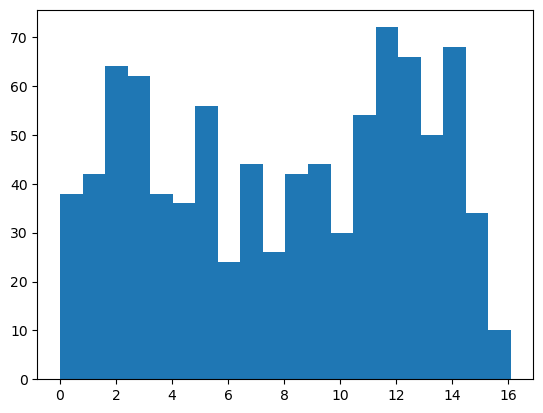

In [15]:
plt.hist(D.reshape(-1), bins=20)
plt.savefig('results/distance_histogram.png')

In [16]:
files
labels = []
for light_curve in files: 
    labels.append(df[df.id==os.path.splitext(os.path.basename(light_curve))[0]]['type'].values[0])


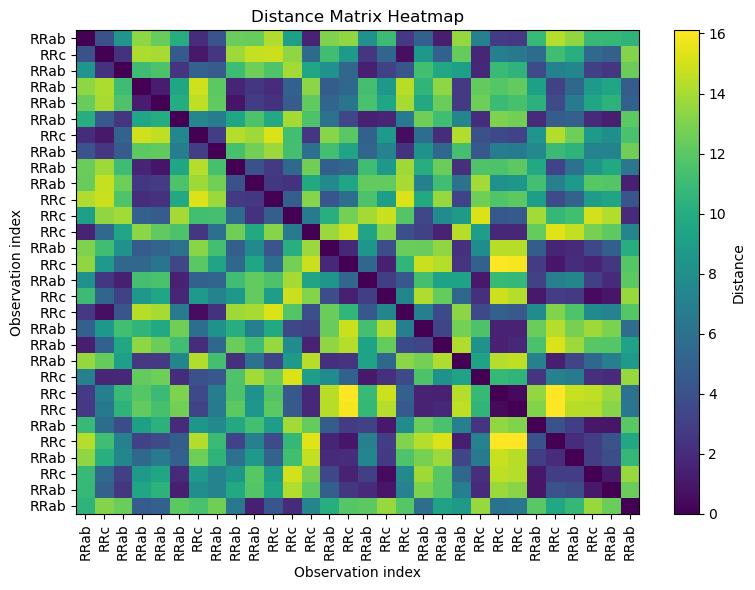

In [17]:
plt.figure(figsize=(8, 6))
im = plt.imshow(D, aspect="auto")
plt.colorbar(im, label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Observation index")
plt.ylabel("Observation index")

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.tight_layout()
plt.savefig('results/heatmap.png')

In [18]:
def plot_original_and_folded(filepath, period=None, star_name=None):
    # Plot original observations and the folded phase-space representation.
    t, mag, err = read_light_curve(filepath)
    if period is None:
        period = periods.get(Path(filepath).stem, None)
    if period is None:
        period = estimate_period(filepath)

    phase = fold_time(t, period)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if err is not None:
        axes[0].errorbar(t, mag, yerr=err, fmt=".", alpha=0.7)
    else:
        axes[0].plot(t, mag, ".", alpha=0.7)

    axes[0].set_title(f"Original: {star_name or Path(filepath).stem}")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Magnitude")
    axes[0].invert_yaxis()
    axes[0].grid(alpha=0.3)

    if err is not None:
        axes[1].errorbar(phase, mag, yerr=err, fmt=".", alpha=0.7)
        axes[1].errorbar(phase + 1, mag, yerr=err, fmt=".", alpha=0.7)
    else:
        axes[1].plot(phase, mag, ".", alpha=0.7)
        axes[1].plot(phase + 1, mag, ".", alpha=0.7)

    axes[1].set_title(f"Folded: {star_name or Path(filepath).stem}\nP = {period:.6f}")
    axes[1].set_xlabel("Phase")
    axes[1].set_ylabel("Magnitude")
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3)

    clean_filepath = filepath.split('/')[2]
    print(clean_filepath, filepath)
    plt.tight_layout()
    plt.savefig("results/"+clean_filepath+".png")



Cluster 0
../data/OGLE-BLG-RRLYR-00002.dat
OGLE-BLG-RRLYR-00002.dat ../data/OGLE-BLG-RRLYR-00002.dat
../data/OGLE-BLG-RRLYR-00007.dat
OGLE-BLG-RRLYR-00007.dat ../data/OGLE-BLG-RRLYR-00007.dat
../data/OGLE-BLG-RRLYR-00018.dat
OGLE-BLG-RRLYR-00018.dat ../data/OGLE-BLG-RRLYR-00018.dat

Cluster 1
../data/OGLE-BLG-RRLYR-00017.dat
OGLE-BLG-RRLYR-00017.dat ../data/OGLE-BLG-RRLYR-00017.dat
../data/OGLE-BLG-RRLYR-00025.dat
OGLE-BLG-RRLYR-00025.dat ../data/OGLE-BLG-RRLYR-00025.dat
../data/OGLE-BLG-RRLYR-00028.dat
OGLE-BLG-RRLYR-00028.dat ../data/OGLE-BLG-RRLYR-00028.dat
../data/OGLE-BLG-RRLYR-00029.dat
OGLE-BLG-RRLYR-00029.dat ../data/OGLE-BLG-RRLYR-00029.dat


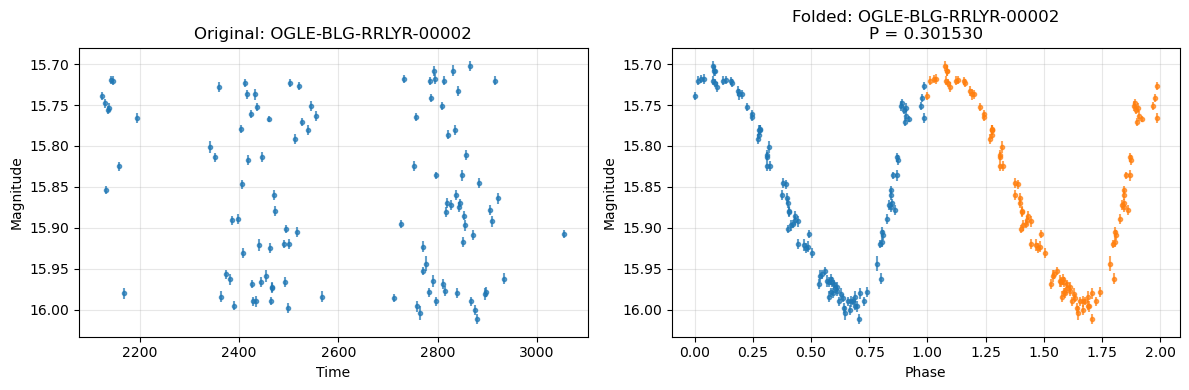

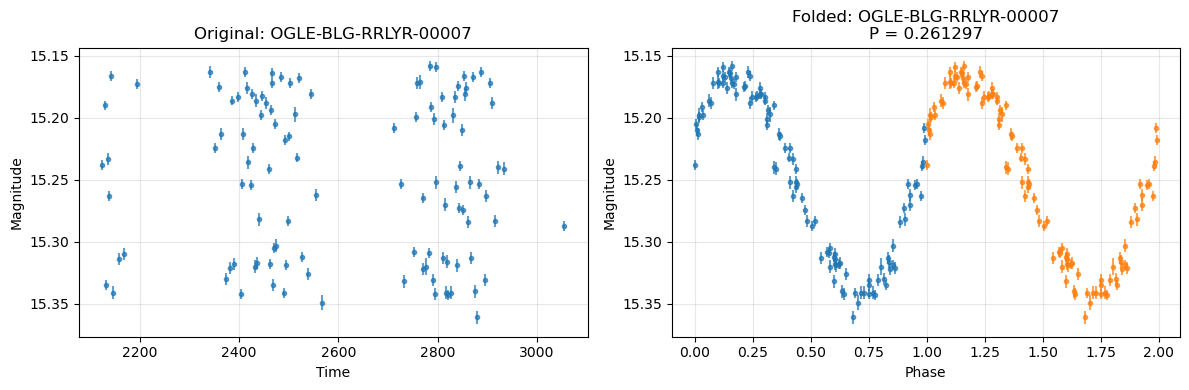

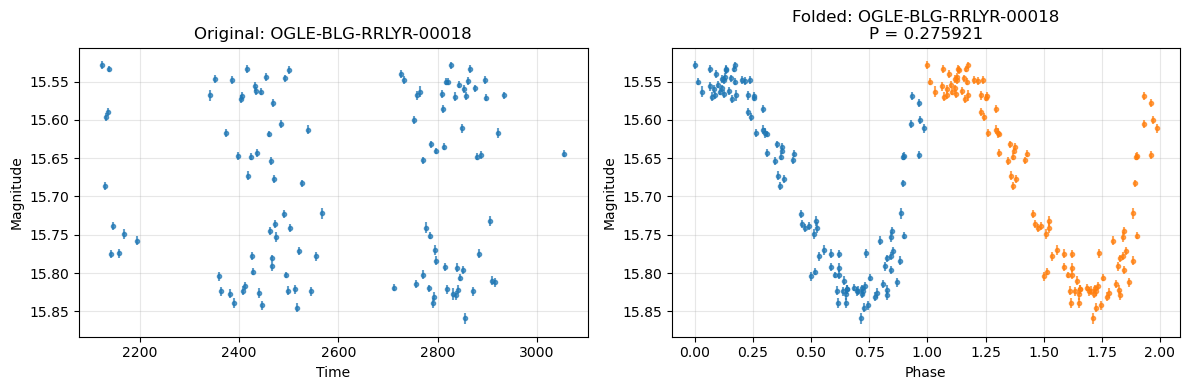

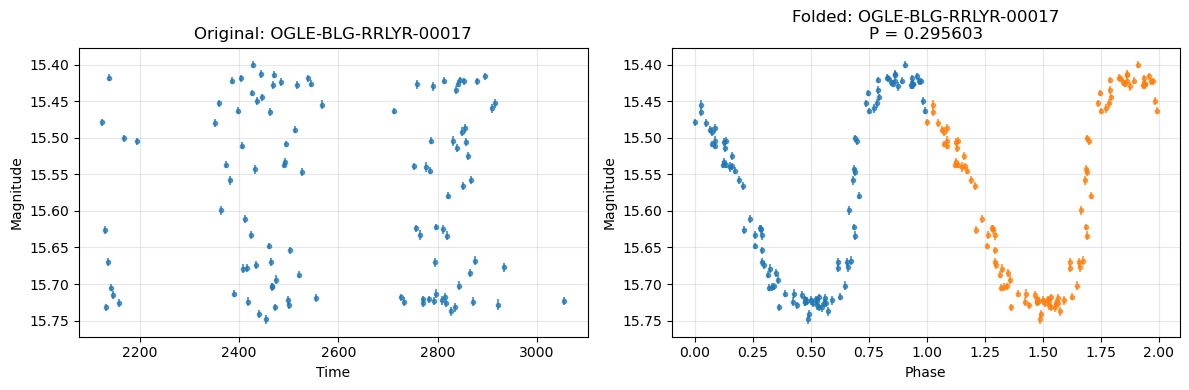

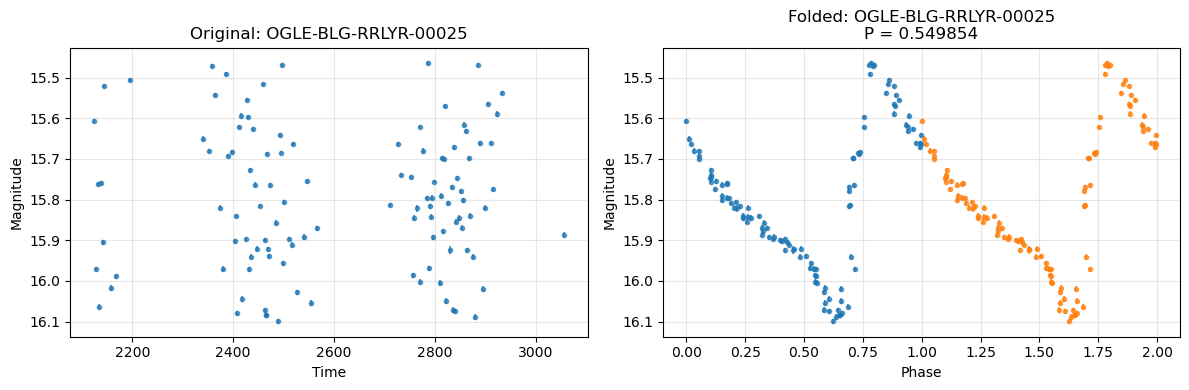

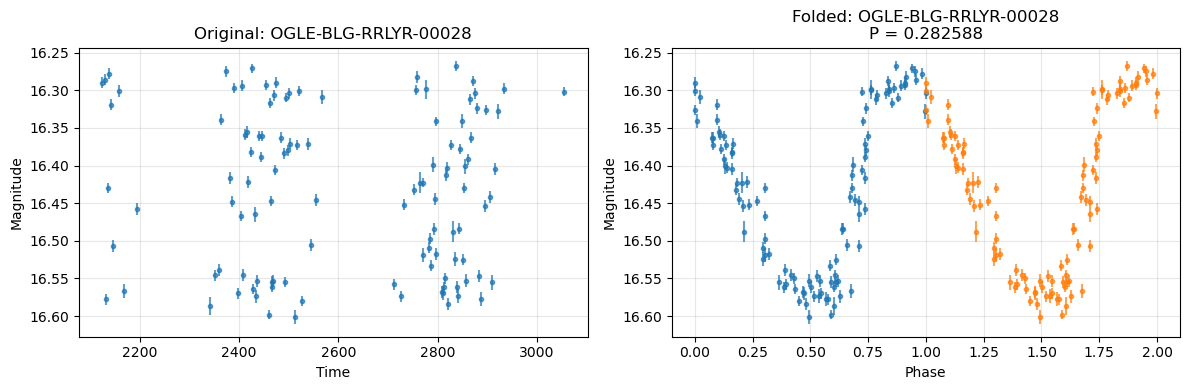

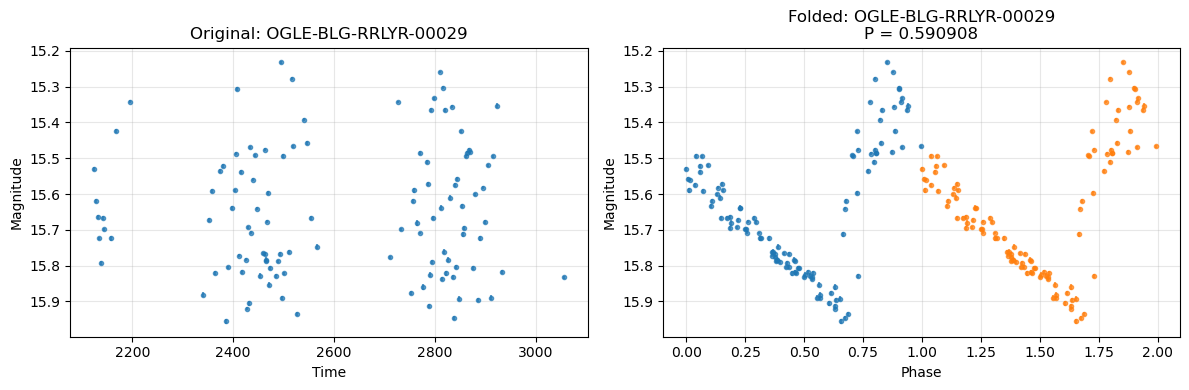

In [19]:
for cluster in objects_by_class.keys():
    print(f"\nCluster {cluster}")
    for star in objects_by_class[cluster]:
        filepath = f"../data/{star}.dat"
        period = periods.get(star, None)
        print(filepath)
        plot_original_and_folded(filepath, period=period, star_name=star)


In [20]:
def purity_score(y_true, y_pred, ignore_noise=True):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if ignore_noise:
        mask = y_pred != -1
        y_true = y_true[mask]
        y_pred = y_pred[mask]

    if len(y_true) == 0:
        return 0.0

    total_correct = 0

    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        true_labels_cluster = y_true[mask]

        if len(true_labels_cluster) > 0:
            total_correct += Counter(true_labels_cluster).most_common(1)[0][1]

    return total_correct / len(y_true)


def get_true_labels_from_clusters(clusters, df, id_col="id", label_col="type"):
    y_true = []
    y_pred = []
    object_ids = []

    df_ids = set(df[id_col].values)

    for cluster_id, cluster_objects in enumerate(clusters):
        for light_curve in cluster_objects:

            # Case 1: cluster stores object IDs
            if light_curve in df_ids:
                label = df.loc[df[id_col] == light_curve, label_col].values[0]
                object_id = light_curve

            # Case 2: cluster stores row indices
            elif isinstance(light_curve, (int, np.integer)) and light_curve < len(df):
                label = df.iloc[light_curve][label_col]
                object_id = df.iloc[light_curve][id_col]

            else:
                print(f"Warning: {light_curve} not found in df")
                continue

            y_true.append(label)
            y_pred.append(cluster_id)
            object_ids.append(object_id)

    return np.array(y_true), np.array(y_pred), np.array(object_ids)


def search_dbscan_by_purity(
    D,
    df,
    eps_values=None,
    min_samples_values=None,
    id_col="id",
    label_col="type",
    ignore_noise=True,
    verbose=True
):


    results = []

    best_model = None
    best_result = None
    best_purity = -np.inf

    for eps in eps_values:
        for min_samples in min_samples_values:

            model = JDRDBSCAN(
                eps=eps,
                min_samples=min_samples,
                verbose=False
            )

            model.fit(D)

            y_true, y_pred, object_ids = get_true_labels_from_clusters(
                clusters=model.clusters_,
                df=df,
                id_col=id_col,
                label_col=label_col
            )

            purity = purity_score(
                y_true=y_true,
                y_pred=y_pred,
                ignore_noise=ignore_noise
            )

            result = {
                "eps": eps,
                "min_samples": min_samples,
                "purity": purity,
                "n_clusters": model.n_clusters_,
                "n_noise": model.n_noise_
            }

            results.append(result)

            if verbose:
                print(
                    f"eps={eps:.4f}, min_samples={min_samples}, "
                    f"purity={purity:.4f}, "
                    f"clusters={model.n_clusters_}, noise={model.n_noise_}"
                )

            if purity > best_purity:
                best_purity = purity
                best_model = model
                best_result = result

    results_df = pd.DataFrame(results).sort_values(
        by=["purity", "n_clusters"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return best_model, best_result, results_df

In [21]:
model = JDRDBSCAN(eps=0.8, min_samples=2, verbose=False)
model.fit(D)

print(model.clusters_)
print(df.head())

[[1, 6, 17], [16, 27], [22, 23]]
                     id     field star_id  type           ra          dec
0  OGLE-BLG-RRLYR-00001  BLG366.6   56455  RRab  17:05:07.49  -32:37:57.2
1  OGLE-BLG-RRLYR-00002  BLG366.8   59262   RRc  17:05:08.09  -32:56:38.1
2  OGLE-BLG-RRLYR-00003  BLG366.6   56524  RRab  17:05:09.88  -32:39:52.8
3  OGLE-BLG-RRLYR-00004  BLG366.7   31697  RRab  17:05:15.22  -32:50:13.2
4  OGLE-BLG-RRLYR-00005  BLG366.6   59764  RRab  17:05:21.99  -32:39:42.5


In [22]:
eps_values = np.linspace(0.2, 100, 1000)
min_samples_values = [2, 3, 4, 5, 6]

best_model, best_result, results_df = search_dbscan_by_purity(
    D=D,
    df=df,
    eps_values=eps_values,
    min_samples_values=min_samples_values,
    id_col="id",
    label_col="type",
    ignore_noise=True
)

print("Best configuration:")
print(best_result)

eps=0.2000, min_samples=2, purity=0.0000, clusters=0, noise=30
eps=0.2000, min_samples=3, purity=0.0000, clusters=0, noise=30
eps=0.2000, min_samples=4, purity=0.0000, clusters=0, noise=30
eps=0.2000, min_samples=5, purity=0.0000, clusters=0, noise=30
eps=0.2000, min_samples=6, purity=0.0000, clusters=0, noise=30
eps=0.2999, min_samples=2, purity=0.0000, clusters=0, noise=30
eps=0.2999, min_samples=3, purity=0.0000, clusters=0, noise=30
eps=0.2999, min_samples=4, purity=0.0000, clusters=0, noise=30
eps=0.2999, min_samples=5, purity=0.0000, clusters=0, noise=30
eps=0.2999, min_samples=6, purity=0.0000, clusters=0, noise=30
eps=0.3998, min_samples=2, purity=0.0000, clusters=0, noise=30
eps=0.3998, min_samples=3, purity=0.0000, clusters=0, noise=30
eps=0.3998, min_samples=4, purity=0.0000, clusters=0, noise=30
eps=0.3998, min_samples=5, purity=0.0000, clusters=0, noise=30
eps=0.3998, min_samples=6, purity=0.0000, clusters=0, noise=30
eps=0.4997, min_samples=2, purity=1.0000, clusters=2, n

In [23]:
results_df.to_csv('results/table.csv')

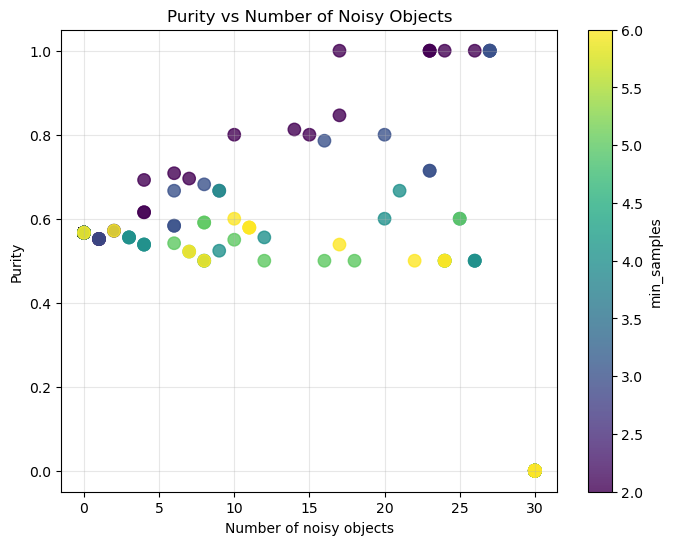

In [24]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    results_df["n_noise"],
    results_df["purity"],
    c=results_df["min_samples"],
    s=80,
    alpha=0.8
)

plt.colorbar(scatter, label="min_samples")

plt.xlabel("Number of noisy objects")
plt.ylabel("Purity")
plt.title("Purity vs Number of Noisy Objects")

plt.grid(alpha=0.3)
plt.savefig('results/purity_number_noise.png')

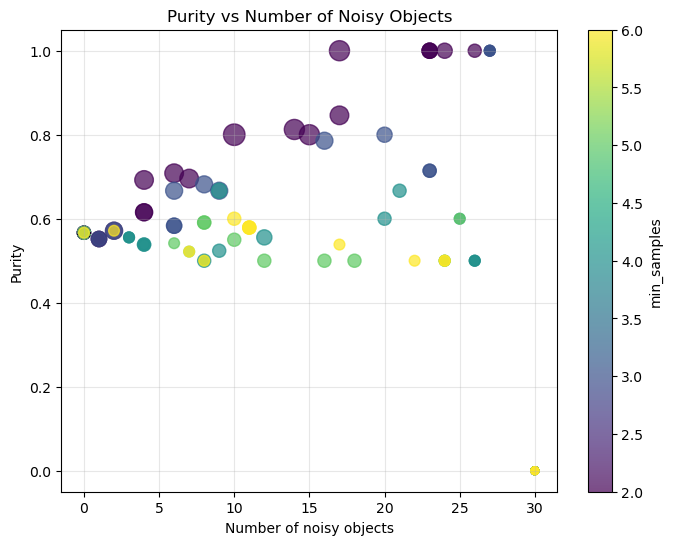

In [25]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    results_df["n_noise"],
    results_df["purity"],
    c=results_df["min_samples"],
    s=30 + 30 * results_df["n_clusters"],
    alpha=0.7
)

plt.colorbar(scatter, label="min_samples")

plt.xlabel("Number of noisy objects")
plt.ylabel("Purity")
plt.title("Purity vs Number of Noisy Objects")

plt.grid(alpha=0.3)
plt.savefig('results/purity_noise_minsamples.png')